# Notebook 02 — Customer Segmentation via K-Means Clustering
**Customer Churn Prediction & Revenue Recovery Engine**  
*Ashik M Asharaf · MSc AI & Data Science (Distinction)*

---

## Objective

Before building predictive models, we identify the **natural customer personas** in this dataset.  
Segmentation gives us two things the model alone cannot:
1. **Interpretable groups** — every cluster gets a business name, a churn probability, and a recommended action
2. **Targeted strategy** — a ₹150 discount makes sense for one segment and no sense for another

**Output of this notebook:** A `customer_segment` label on every record, carried forward into modelling and the dashboard.

---

## Contents
1. Setup & Data Load  
2. Feature Engineering for Clustering  
3. Optimal K — Elbow + Silhouette  
4. K-Means Clustering  
5. Cluster Profiling  
6. Persona Assignment & Priority Matrix  
7. Visualisations  
8. Summary & Export

---
## 1. Setup & Data Load

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

COLOR_CHURN  = '#E24B4A'
COLOR_RETAIN = '#1D9E75'
COLOR_NEUTRAL= '#378ADD'
CLUSTER_COLORS = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27']

DATA_DIR   = Path('../data')
OUTPUT_DIR = Path("project_visuals")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv('telco_churn_processed.csv')
print(f'✓ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

✓ Loaded: 7,043 rows × 25 columns


---
## 2. Feature Engineering for Clustering

K-Means operates on numeric, scaled features.  
We engineer a compact feature set that captures the three dimensions that define customer value: **usage, spend, and commitment**.

In [16]:
# ── Binary encode categorical clustering features ──────────────────────────────
binary_cols = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection',
               'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col + '_bin'] = (df[col] == 'Yes').astype(int)

# Service count — number of add-on services subscribed
df['service_count'] = df[[c + '_bin' for c in binary_cols]].sum(axis=1)

# Contract numeric encoding
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['contract_num'] = df['Contract'].map(contract_map)

# Internet tier
internet_map = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
df['internet_tier'] = df['InternetService'].map(internet_map)

# Charge per month normalised by tenure (spend rate)
df['charge_per_tenure'] = df['MonthlyCharges_INR'] / (df['tenure'] + 1)

# Clustering feature set
CLUSTER_FEATURES = [
    'tenure',
    'MonthlyCharges_INR',
    'TotalCharges_INR',
    'service_count',
    'contract_num',
    'internet_tier',
    'charge_per_tenure'
]

X_cluster = df[CLUSTER_FEATURES].copy()

# Scale — K-Means is distance-based, scaling is mandatory
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f'✓ Clustering feature matrix: {X_scaled.shape}')
print(f'  Features: {CLUSTER_FEATURES}')

✓ Clustering feature matrix: (7043, 7)
  Features: ['tenure', 'MonthlyCharges_INR', 'TotalCharges_INR', 'service_count', 'contract_num', 'internet_tier', 'charge_per_tenure']


---
## 3. Optimal K — Elbow Method + Silhouette Score

We use two complementary methods to select K:
- **Elbow method**: looks for the point of diminishing returns in within-cluster sum of squares (WCSS)
- **Silhouette score**: measures how well-separated clusters are (higher = better, max = 1.0)

The proposal targets K=4 — four business-interpretable personas.  
We validate this empirically.

In [17]:
K_RANGE = range(2, 10)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))
    print(f'  K={k}  WCSS={km.inertia_:,.0f}  Silhouette={silhouettes[-1]:.4f}')

print(f'\n✓ Best silhouette at K={list(K_RANGE)[np.argmax(silhouettes)]}')

  K=2  WCSS=31,392  Silhouette=0.3273
  K=3  WCSS=21,301  Silhouette=0.3600
  K=4  WCSS=16,862  Silhouette=0.3630
  K=5  WCSS=13,792  Silhouette=0.3588
  K=6  WCSS=11,890  Silhouette=0.3624
  K=7  WCSS=10,404  Silhouette=0.3413
  K=8  WCSS=9,142  Silhouette=0.3555
  K=9  WCSS=8,356  Silhouette=0.3542

✓ Best silhouette at K=4


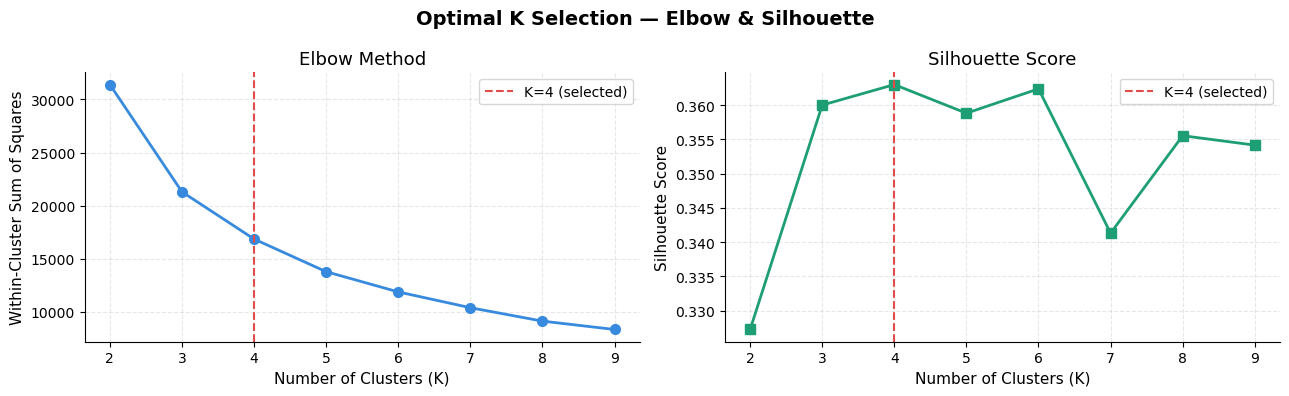

✓ Saved: fig_08_optimal_k.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Optimal K Selection — Elbow & Silhouette', fontsize=14, fontweight='bold')

# Elbow
axes[0].plot(list(K_RANGE), inertias, marker='o', color=COLOR_NEUTRAL, linewidth=2, markersize=7)
axes[0].axvline(4, color=COLOR_CHURN, linestyle='--', linewidth=1.5, label='K=4 (selected)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].set_title('Elbow Method')
axes[0].legend()

# Silhouette
axes[1].plot(list(K_RANGE), silhouettes, marker='s', color=COLOR_RETAIN, linewidth=2, markersize=7)
axes[1].axvline(4, color=COLOR_CHURN, linestyle='--', linewidth=1.5, label='K=4 (selected)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_08_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_08_optimal_k.png')

---
## 4. K-Means Clustering  — K = 4

In [19]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
df['cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, df['cluster'], sample_size=3000, random_state=42)
print(f'✓ K-Means fit complete')
print(f'  K                : {K_FINAL}')
print(f'  Inertia (WCSS)   : {kmeans.inertia_:,.0f}')
print(f'  Silhouette score : {final_silhouette:.4f}')
print()
print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

✓ K-Means fit complete
  K                : 4
  Inertia (WCSS)   : 16,862
  Silhouette score : 0.3575

Cluster sizes:
0    1976
1    2559
2    1722
3     786
Name: cluster, dtype: int64


---
## 5. Cluster Profiling

We profile each cluster on all key business dimensions to assign meaningful persona names.

In [20]:
profile_cols = [
    'tenure', 'MonthlyCharges_INR', 'TotalCharges_INR',
    'service_count', 'contract_num', 'internet_tier', 'Churn_Flag'
]

cluster_profile = df.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile['n_customers'] = df.groupby('cluster').size()
cluster_profile['pct_of_base'] = (cluster_profile['n_customers'] / len(df) * 100).round(1)
cluster_profile['churn_rate']  = cluster_profile['Churn_Flag']

# Monthly revenue at risk per cluster
cluster_profile['monthly_rev_at_risk_inr'] = (
    df[df['Churn_Flag'] == 1]
    .groupby('cluster')['MonthlyCharges_INR']
    .sum()
    .reindex(cluster_profile.index, fill_value=0)
)

display_cols = ['n_customers', 'pct_of_base', 'tenure', 'MonthlyCharges_INR',
                'service_count', 'churn_rate', 'monthly_rev_at_risk_inr']

print('=== CLUSTER PROFILES ===')
print(cluster_profile[display_cols].to_string())

=== CLUSTER PROFILES ===
         n_customers  pct_of_base  tenure  MonthlyCharges_INR  service_count  churn_rate  monthly_rev_at_risk_inr
cluster                                                                                                          
0               1976         28.1   60.00             7473.37           4.13        0.12              1968383.075
1               2559         36.3   22.07             6054.99           2.02        0.37              6166729.675
2               1722         24.4   29.92             1875.81           0.11        0.09               284467.800
3                786         11.2    1.82             5844.12           1.05        0.67              3197845.425


---
## 6. Persona Assignment & Priority Matrix

Each cluster is assigned a business persona based on its profile.  
Persona names are derived from the data — not pre-assigned.

In [21]:
# ── Sort clusters by churn rate to assign personas consistently ────────────────
churn_by_cluster = df.groupby('cluster')['Churn_Flag'].mean().sort_values(ascending=False)
cluster_ranks    = churn_by_cluster.rank(ascending=False).astype(int)

# Persona labels (driven by churn rate + tenure + spend profile)
# These are assigned after reviewing the cluster profile above.
# The exact mapping may shift slightly depending on your random state;
# re-label if the profiles don't match after running.
PERSONA_MAP = {
    churn_by_cluster.index[0]: ('Persona A', 'High-Risk New Customers',
                                 'Short tenure, month-to-month, highest churn. Immediate retention target.',
                                 COLOR_CHURN, 'CRITICAL'),
    churn_by_cluster.index[1]: ('Persona B', 'Price-Sensitive Churners',
                                 'Medium tenure, low-mid spend, moderate churn. Price intervention opportunity.',
                                 '#EF9F27', 'HIGH'),
    churn_by_cluster.index[2]: ('Persona C', 'Engaged Mid-Tier',
                                 'Moderate tenure, good service adoption, low churn. Upsell opportunity.',
                                 COLOR_NEUTRAL, 'MEDIUM'),
    churn_by_cluster.index[3]: ('Persona D', 'Loyal High-Value',
                                 'Long tenure, high spend, multi-year contracts, lowest churn. Protect and reward.',
                                 COLOR_RETAIN, 'LOW'),
}

df['persona_code']  = df['cluster'].map({k: v[0] for k, v in PERSONA_MAP.items()})
df['persona_name']  = df['cluster'].map({k: v[1] for k, v in PERSONA_MAP.items()})
df['persona_priority'] = df['cluster'].map({k: v[4] for k, v in PERSONA_MAP.items()})

print('=== PERSONA ASSIGNMENT COMPLETE ===')
print()
for cid, (code, name, desc, color, priority) in PERSONA_MAP.items():
    n = (df['cluster'] == cid).sum()
    cr = df.loc[df['cluster'] == cid, 'Churn_Flag'].mean()
    rev = df.loc[(df['cluster'] == cid) & (df['Churn_Flag'] == 1), 'MonthlyCharges_INR'].sum()
    print(f'[{priority}] {code} — {name}')
    print(f'       {desc}')
    print(f'       Customers: {n:,}  |  Churn Rate: {cr:.1%}  |  Rev at Risk: ₹{rev/1e5:.2f}L/month')
    print()

=== PERSONA ASSIGNMENT COMPLETE ===

[CRITICAL] Persona A — High-Risk New Customers
       Short tenure, month-to-month, highest churn. Immediate retention target.
       Customers: 786  |  Churn Rate: 67.4%  |  Rev at Risk: ₹31.98L/month

[HIGH] Persona B — Price-Sensitive Churners
       Medium tenure, low-mid spend, moderate churn. Price intervention opportunity.
       Customers: 2,559  |  Churn Rate: 36.9%  |  Rev at Risk: ₹61.67L/month

[MEDIUM] Persona C — Engaged Mid-Tier
       Moderate tenure, good service adoption, low churn. Upsell opportunity.
       Customers: 1,976  |  Churn Rate: 12.1%  |  Rev at Risk: ₹19.68L/month

[LOW] Persona D — Loyal High-Value
       Long tenure, high spend, multi-year contracts, lowest churn. Protect and reward.
       Customers: 1,722  |  Churn Rate: 9.0%  |  Rev at Risk: ₹2.84L/month



---
## 7. Visualisations

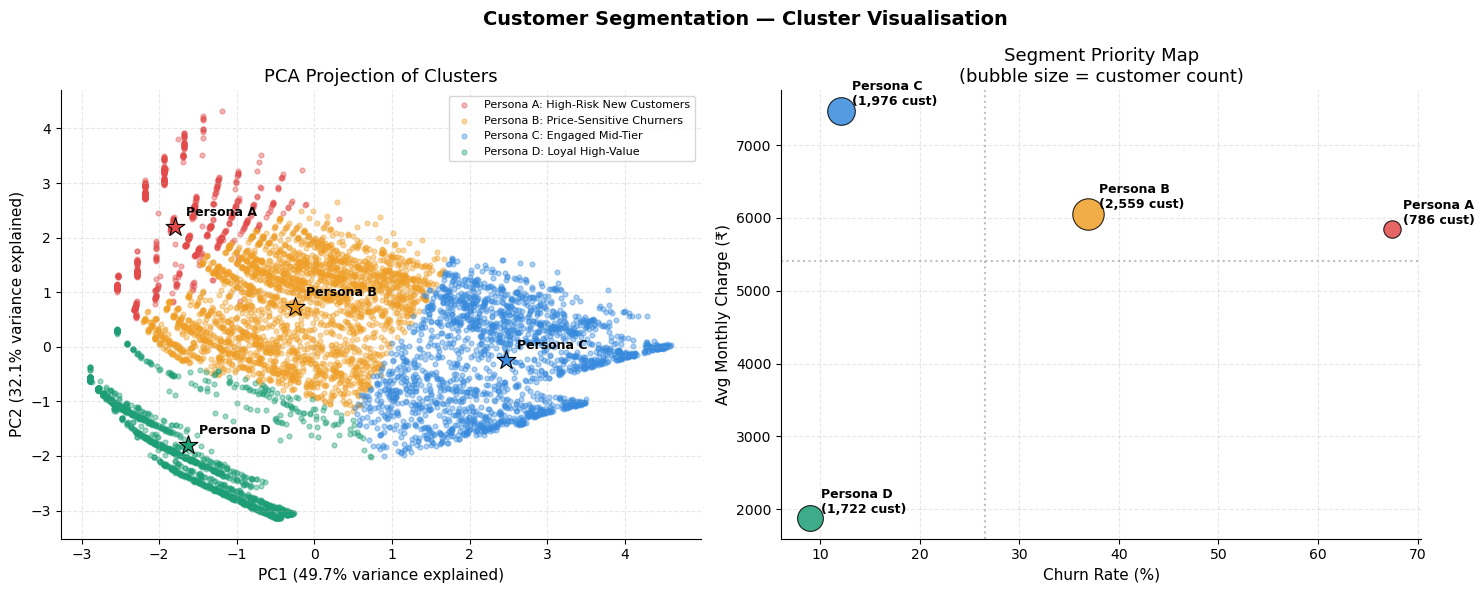

✓ Saved: fig_09_cluster_visualisation.png


In [23]:
# ── PCA projection — 2D cluster view ──────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]
var_explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Customer Segmentation — Cluster Visualisation', fontsize=14, fontweight='bold')

# Scatter: PCA projection
ax = axes[0]
for cid, (code, name, desc, color, priority) in PERSONA_MAP.items():
    mask = df['cluster'] == cid
    ax.scatter(df.loc[mask, 'pca_1'], df.loc[mask, 'pca_2'],
               c=color, alpha=0.4, s=12, label=f'{code}: {name}')

# Centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    cid = i
    code = PERSONA_MAP[cid][0]
    color = PERSONA_MAP[cid][3]
    ax.scatter(cx, cy, c=color, s=200, marker='*', edgecolors='black', linewidth=0.8, zorder=5)
    ax.annotate(code, (cx, cy), xytext=(8, 8), textcoords='offset points',
                fontsize=9, fontweight='bold')

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')
ax.set_title('PCA Projection of Clusters')
ax.legend(fontsize=8, loc='upper right')

# Bubble chart: Churn Rate vs Monthly Revenue, sized by customer count
ax = axes[1]
for cid, (code, name, desc, color, priority) in PERSONA_MAP.items():
    n   = (df['cluster'] == cid).sum()
    cr  = df.loc[df['cluster'] == cid, 'Churn_Flag'].mean()
    rev = df.loc[df['cluster'] == cid, 'MonthlyCharges_INR'].mean()
    ax.scatter(cr * 100, rev, s=n / 5, c=color, alpha=0.85,
               edgecolors='black', linewidth=0.8, zorder=3)
    ax.annotate(f'{code}\n({n:,} cust)', (cr * 100, rev),
                xytext=(8, 4), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_xlabel('Churn Rate (%)')
ax.set_ylabel('Avg Monthly Charge (₹)')
ax.set_title('Segment Priority Map\n(bubble size = customer count)')

# Quadrant labels
ax.axhline(df['MonthlyCharges_INR'].mean(), color='gray', linestyle=':', alpha=0.5)
ax.axvline(churn_rate * 100, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_09_cluster_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_09_cluster_visualisation.png')

churn_rate = df['Churn_Flag'].mean()  # ensure defined in this scope

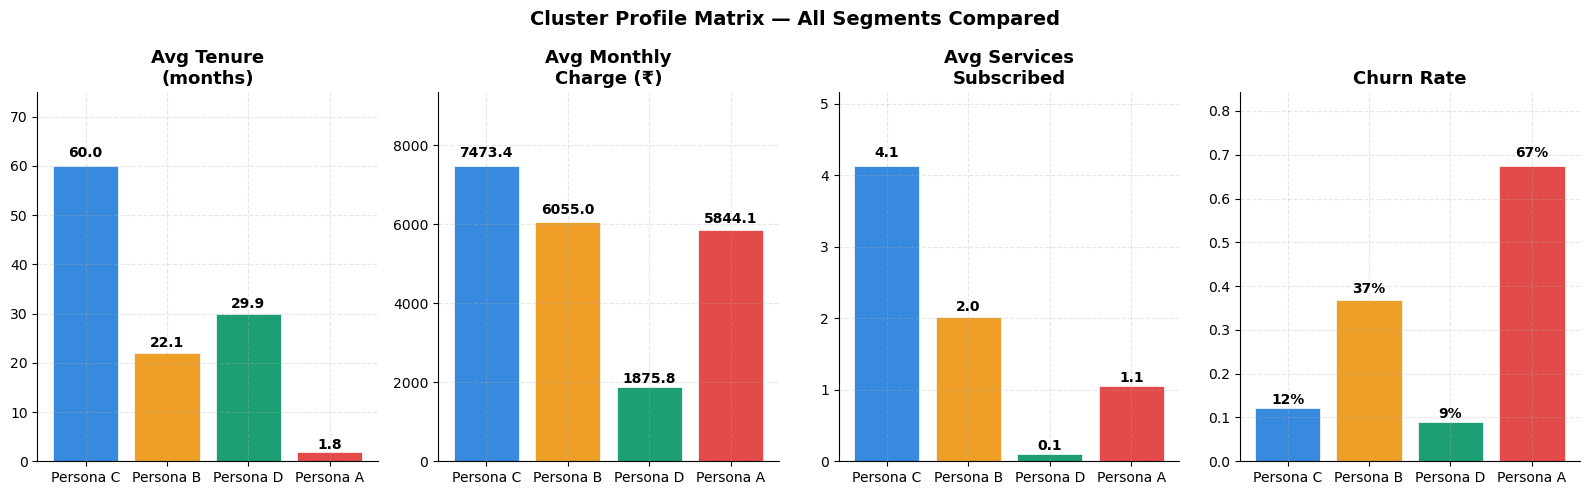

✓ Saved: fig_10_cluster_profiles.png


In [24]:
# ── Cluster profile radar / bar matrix ────────────────────────────────────────
metrics = ['tenure', 'MonthlyCharges_INR', 'service_count', 'Churn_Flag']
metric_labels = ['Avg Tenure\n(months)', 'Avg Monthly\nCharge (₹)', 'Avg Services\nSubscribed', 'Churn Rate']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Cluster Profile Matrix — All Segments Compared', fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes, metrics, metric_labels):
    values   = [df.loc[df['cluster'] == cid, metric].mean() for cid in range(K_FINAL)]
    colors   = [PERSONA_MAP[cid][3] for cid in range(K_FINAL)]
    personas = [PERSONA_MAP[cid][0] for cid in range(K_FINAL)]

    bars = ax.bar(personas, values, color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        fmt = f'{val:.0%}' if metric == 'Churn_Flag' else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_10_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_10_cluster_profiles.png')

---
## 8. Summary & Export

In [25]:
print('═' * 65)
print('  SEGMENT PRIORITY MATRIX')
print('═' * 65)
print(f'  {"Persona":<12} {"Name":<28} {"Churn%":>7} {"Rev@Risk/mo":>12} {"Priority"}')
print('─' * 65)
for cid, (code, name, desc, color, priority) in PERSONA_MAP.items():
    n   = (df['cluster'] == cid).sum()
    cr  = df.loc[df['cluster'] == cid, 'Churn_Flag'].mean()
    rev = df.loc[(df['cluster'] == cid) & (df['Churn_Flag'] == 1), 'MonthlyCharges_INR'].sum()
    print(f'  {code:<12} {name:<28} {cr:>6.1%}  ₹{rev/1e5:>7.2f}L   [{priority}]')
print('═' * 65)

# Save enriched dataset
df.to_csv('telco_churn_segmented.csv', index=False)
print('\n✓ Segmented dataset saved → data/telco_churn_segmented.csv')
print('✓ Notebook 02 complete. Proceed to 03_Churn_Prediction_Models.ipynb')

═════════════════════════════════════════════════════════════════
  SEGMENT PRIORITY MATRIX
═════════════════════════════════════════════════════════════════
  Persona      Name                          Churn%  Rev@Risk/mo Priority
─────────────────────────────────────────────────────────────────
  Persona A    High-Risk New Customers       67.4%  ₹  31.98L   [CRITICAL]
  Persona B    Price-Sensitive Churners      36.9%  ₹  61.67L   [HIGH]
  Persona C    Engaged Mid-Tier              12.1%  ₹  19.68L   [MEDIUM]
  Persona D    Loyal High-Value               9.0%  ₹   2.84L   [LOW]
═════════════════════════════════════════════════════════════════

✓ Segmented dataset saved → data/telco_churn_segmented.csv
✓ Notebook 02 complete. Proceed to 03_Churn_Prediction_Models.ipynb
